# Importation des modules

In [118]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme()
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score

# Préparation des données

In [119]:
auteurs_nat_df = pd.read_csv('data/AuteursNat.csv')  # Contient les informations sur les années de naissance des auteurs
auteurs_df = pd.read_csv('data/Auteurs.csv', sep = " ")  # Contient les données sur l'utilisation des mots par auteur


In [120]:
auteurs_nat_df.head()

# Afficher les informations générales sur le DataFrame (types de données, valeurs manquantes)
auteurs_nat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Nom        39 non-null     object
 1   Naissance  39 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 752.0+ bytes


In [121]:
auteurs_df.head()

# Afficher les informations générales sur le DataFrame des mots
auteurs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Columns: 15519 entries, voc to trouvère
dtypes: object(15519)
memory usage: 4.7+ MB


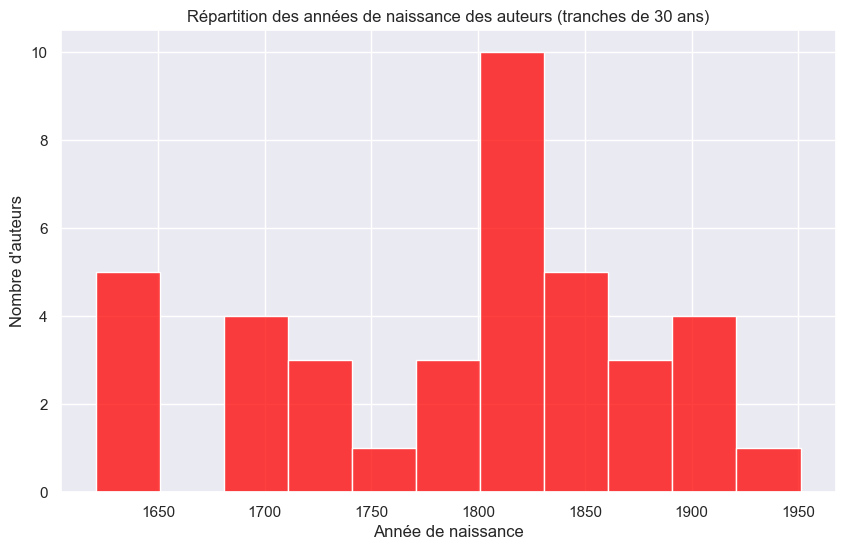

In [122]:
# Trancher les années en intervalles de 30 ans
bins_30 = np.arange(auteurs_nat_df['Naissance'].min(), auteurs_nat_df['Naissance'].max() + 30, 30)
plt.figure(figsize=(10, 6))
sns.histplot(auteurs_nat_df['Naissance'], bins=bins_30, kde=False, color='red')
plt.title('Répartition des années de naissance des auteurs (tranches de 30 ans)')
plt.xlabel('Année de naissance')
plt.ylabel('Nombre d\'auteurs')
plt.show()

In [123]:
# Exclure la colonne des noms des auteurs pour ne garder que les mots
mots_colonnes = auteurs_df.columns.difference(["voc"])

# Conversion en numérique pour éviter les erreurs
auteurs_df[mots_colonnes] = auteurs_df[mots_colonnes].apply(pd.to_numeric, errors="coerce")

# Trouver le mot le plus fréquent pour chaque auteur
auteurs_df["MotPlusFrequent"] = auteurs_df[mots_colonnes].idxmax(axis=1)

# Afficher les résultats
print(auteurs_df[["voc", "MotPlusFrequent"]])


              voc MotPlusFrequent
0            gram             NaN
1         AFrance            être
2          Aragon            être
3          Balzac            être
4      Baudelaire            être
5         Bruyere            être
6           Camus            être
7   Chateaubriand            être
8       Corneille            être
9         Diderot            être
10          Dumas            être
11        Echenoz            être
12         Eluard            être
13       Flaubert            être
14      Giraudoux            être
15          Gracq            être
16      HugoProse            être
17       HugoVers            être
18     LaFontaine            être
19       Marivaux            être
20     Maupassant            être
21        Moliere            être
22    Montesquieu            être
23         Musset            être
24         Nerval            être
25         Pascal            être
26          Perse            être
27         Proust            être
28         Rac

/var/folders/fn/0zxlxwm500b7hng2w4pssfbr0000gn/T/ipykernel_77414/110131231.py:8: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  auteurs_df["MotPlusFrequent"] = auteurs_df[mots_colonnes].idxmax(axis=1)
/var/folders/fn/0zxlxwm500b7hng2w4pssfbr0000gn/T/ipykernel_77414/110131231.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  auteurs_df["MotPlusFrequent"] = auteurs_df[mots_colonnes].idxmax(axis=1)


In [124]:
# Exclusion des colonnes "voc", "être" et "ne" pour l'analyse
mots_colonnes = auteurs_df.columns.difference(["voc", "être", "ne"])

# Conversion en numérique pour éviter les erreurs
auteurs_df[mots_colonnes] = auteurs_df[mots_colonnes].apply(pd.to_numeric, errors="coerce")

# Trouver le mot le plus fréquent après suppression de "être"
auteurs_df["MotPlusFrequent"] = auteurs_df[mots_colonnes].idxmax(axis=1)

# Afficher les résultats
print(auteurs_df[["voc", "MotPlusFrequent"]])


              voc MotPlusFrequent
0            gram             NaN
1         AFrance             pas
2          Aragon             pas
3          Balzac            dire
4      Baudelaire            tout
5         Bruyere           faire
6           Camus             pas
7   Chateaubriand            tout
8       Corneille           faire
9         Diderot             pas
10          Dumas            dire
11        Echenoz             pas
12         Eluard            tout
13       Flaubert            tout
14      Giraudoux             pas
15          Gracq            tout
16      HugoProse            tout
17       HugoVers            tout
18     LaFontaine           faire
19       Marivaux             pas
20     Maupassant            tout
21        Moliere           faire
22    Montesquieu           faire
23         Musset             pas
24         Nerval            tout
25         Pascal             pas
26          Perse           grand
27         Proust             pas
28         Rac

/var/folders/fn/0zxlxwm500b7hng2w4pssfbr0000gn/T/ipykernel_77414/2991814082.py:8: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  auteurs_df["MotPlusFrequent"] = auteurs_df[mots_colonnes].idxmax(axis=1)


/var/folders/fn/0zxlxwm500b7hng2w4pssfbr0000gn/T/ipykernel_77414/2613214646.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_mots.values, y=top_mots.index, palette="coolwarm")


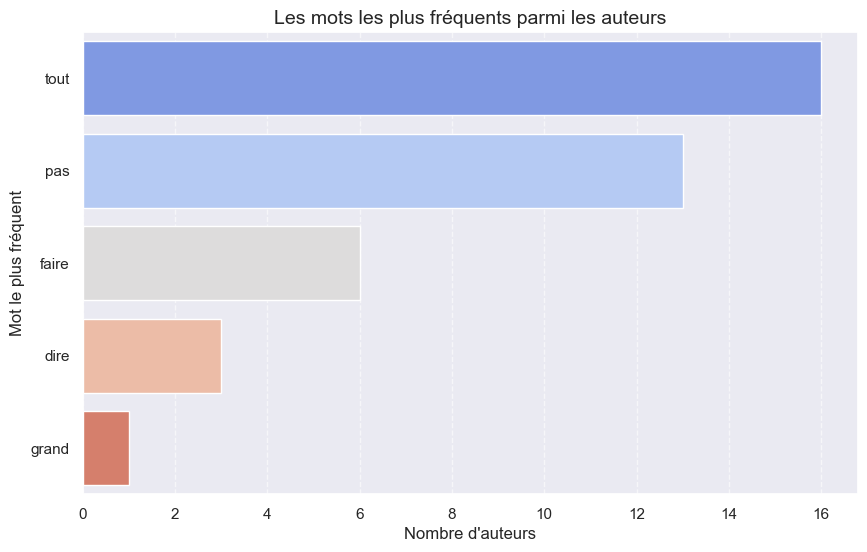

In [125]:
# Supprimer la première ligne de auteurs_df (qui contient le type grammatical)
auteurs_df_2 = auteurs_df.iloc[1:].reset_index(drop=True)
# Compter combien de fois chaque mot est le plus fréquent
mots_counts = auteurs_df_2["MotPlusFrequent"].value_counts()

# Sélectionner les 15 mots les plus fréquents pour une meilleure lisibilité
top_mots = mots_counts.head(15)

# Créer un graphique en barres horizontales
plt.figure(figsize=(10, 6))
sns.barplot(x=top_mots.values, y=top_mots.index, palette="coolwarm")

# Ajouter des titres et labels
plt.xlabel("Nombre d'auteurs", fontsize=12)
plt.ylabel("Mot le plus fréquent", fontsize=12)
plt.title("Les mots les plus fréquents parmi les auteurs", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Afficher le graphique
plt.show()

# Étude selon les classes grammaticales

Sélection du dataframe en ne gardant que les noms et les adjectifs

In [126]:
auteurs = pd.read_csv("data/Auteurs.csv", sep = " ")
auteurs.head()

,voc,être,ne,pas,tout,faire,dire,plus,pouvoir,voir,...,pécore,peiner,plantureux,poivrer,pourchas,rebiffer,renoncule,supputer,trembloter,trouvère
0,gram,VER,ADV,ADV,ADJ,VER,VER,ADV,VER,VER,...,NOM,VER,ADJ,VER,NOM,VER,NOM,VER,VER,NOM
1,AFrance,31268,17065,8332,7191,6039,5890,5681,3859,3698,...,0,0,0,0,0,0,0,0,0,0
2,Aragon,76567,43430,29516,21004,17452,15358,11270,14416,8095,...,0,0,0,0,0,0,0,0,0,0
3,Balzac,81565,44549,23372,22075,21780,26337,16447,15791,11856,...,0,0,0,0,0,0,0,0,0,0
4,Baudelaire,9021,3737,2070,2828,1747,1250,2369,1495,762,...,0,0,0,0,0,0,0,0,0,0


In [130]:
## Nombre de mots par classe grammaticale  POUR CHAQUE AUTEUR

auteurs = pd.read_csv("data/Auteurs.csv", sep=" ")

# Extraire les classes grammaticales (ligne 1 du fichier)
gram_classes = auteurs.iloc[0, 1:]  # On prend tout sauf la colonne "voc"

# Créer un dictionnaire {mot : classe grammaticale}
gram_dict = dict(zip(auteurs.columns[1:], gram_classes))

# Supprimer la ligne des classes grammaticales pour ne garder que les données numériques
auteurs_data = auteurs.iloc[1:].set_index("voc").astype(int)

# Regrouper par classe grammaticale et sommer
class_sums = auteurs_data.groupby(gram_dict, axis=1).sum()

# Afficher le résultat
print(class_sums)

                  ADJ     ADV     NOM     VER
voc                                          
AFrance         71172   65785  195962  154124
Aragon         140084  183575  453357  392505
Balzac         202921  195497  656803  553187
Baudelaire      26425   21733   59399   40173
Bruyere          8383   10322   20723   22515
Camus           24469   33050   72370   67109
Chateaubriand   97955   88722  357211  252947
Corneille       26109   37023   83001   92363
Diderot         25501   34941   82864   76292
Dumas          215709  276619  800989  778493
Echenoz         36259   51260  110924   99833
Eluard          21231   16745   66529   39445
Flaubert        40098   40655  143009  113329
Giraudoux       24737   32486   81703   65532
Gracq           53589   51792  146352   92675
HugoProse      180162  164155  553384  451241
HugoVers        38871   20293  109200   74335
LaFontaine      17437   24779   56179   52684
Marivaux        36852   82263  120695  157586
Maupassant      88457   85444  236

/var/folders/fn/0zxlxwm500b7hng2w4pssfbr0000gn/T/ipykernel_77414/1061139725.py:15: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  class_sums = auteurs_data.groupby(gram_dict, axis=1).sum()


In [131]:
# Charger les données
auteurs = pd.read_csv("data/Auteurs.csv", sep=" ")

# Extraire les classes grammaticales (ligne 1, sans la colonne "voc")
gram_classes = auteurs.iloc[0, 1:]

# Compter combien de mots sont classifiés dans chaque catégorie
class_counts = gram_classes.value_counts()

# Afficher le résultat
print(class_counts)

0
NOM    9604
ADJ    2716
VER    2424
ADV     774
Name: count, dtype: int64


/var/folders/fn/0zxlxwm500b7hng2w4pssfbr0000gn/T/ipykernel_77414/1145141735.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


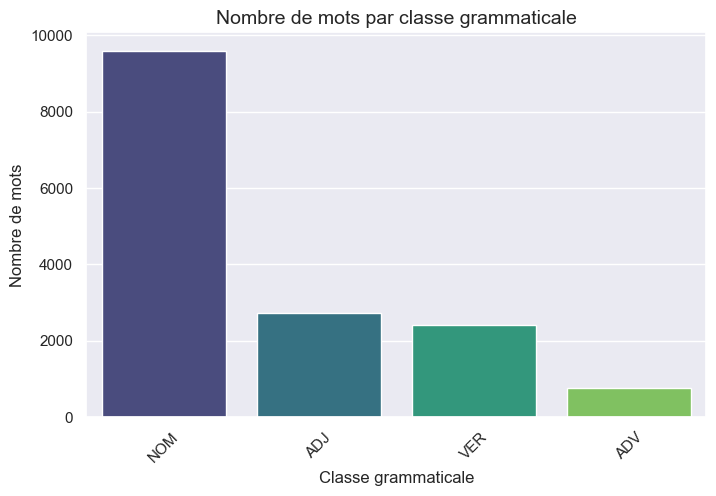

In [132]:
# Extraire les classes grammaticales (ligne 1, sans la colonne "voc")
gram_classes = auteurs.iloc[0, 1:]

# Compter combien de mots sont classifiés dans chaque catégorie
class_counts = gram_classes.value_counts()

# Tracer le barplot
plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")

# Ajouter des labels
plt.xlabel("Classe grammaticale", fontsize=12)
plt.ylabel("Nombre de mots", fontsize=12)
plt.title("Nombre de mots par classe grammaticale", fontsize=14)
plt.xticks(rotation=45)
plt.show()

              voc   tout autre grand petit   bon  beau  seul premier jeune  \
0         AFrance   7191  1639  2546  2168  1860  1508   919     828  1078   
1          Aragon  21004  6771  4850  5532  2215  2296  2062    2261  2027   
2          Balzac  22075  4368  6296  5967  3531  4620  3573    3696  5176   
3      Baudelaire   2828   735   875   363   396   618   232     267   201   
4         Bruyere   1169   672   573   148   207   181   193     146    58   
5           Camus   3508  1104   748   442   372   186   801     547   210   
6   Chateaubriand   9799  3664  3886  1567   949  1438  1653    2583  1347   
7       Corneille   4321  1457  1248    55   387   653   751     301    84   
8         Diderot   3481  1673   938   643   682   741   450     659   327   
9           Dumas  30215  8955  6941  4085  5385  4085  4718    5437  6569   
10        Echenoz   4434  2286   743  1447   850   256   727     690   595   
11         Eluard   2827   711   710   473   271   516   517    

/var/folders/fn/0zxlxwm500b7hng2w4pssfbr0000gn/T/ipykernel_77414/3843598948.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_mots.values, y=top_mots.index, palette="coolwarm")


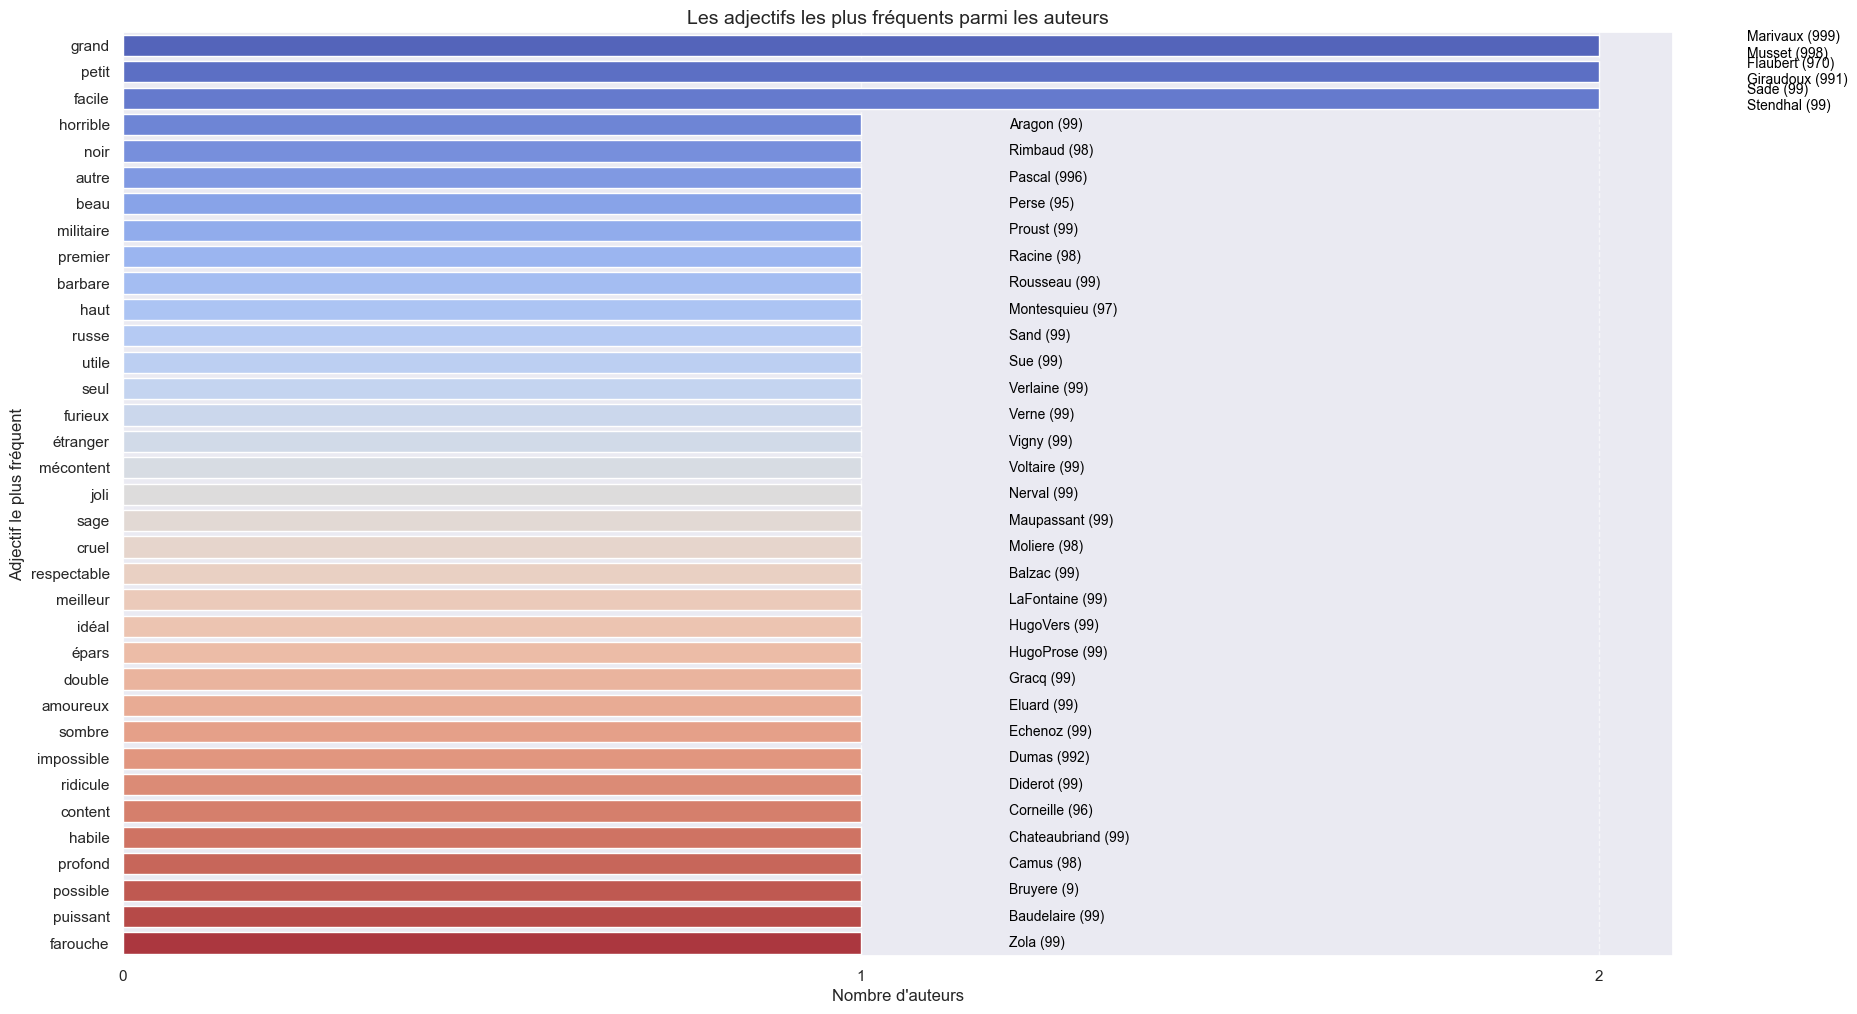

In [127]:
# Sélectionner uniquement les colonnes où la première ligne (index 0) est "ADJ"
auteurs_adj = auteurs.loc[:, auteurs.iloc[0] == "ADJ"]

# Ajouter la colonne des auteurs
auteurs_adj.insert(0, "voc", auteurs["voc"])

# Supprimer la ligne d'étiquettes grammaticales
auteurs_adj = auteurs_adj.drop(index=0).reset_index(drop=True)

print(auteurs_adj)

# Supprimer la première ligne qui contient les types grammaticaux
auteurs_adj_2 = auteurs_adj.iloc[1:].reset_index(drop=True)

# Trouver l'adjectif le plus utilisé pour chaque auteur
auteurs_adj_2["MotPlusFrequent"] = auteurs_adj_2.iloc[:, 1:].idxmax(axis=1)

# Compter combien de fois chaque adjectif est le plus fréquent
mots_counts = auteurs_adj_2["MotPlusFrequent"].value_counts()

# Sélectionner les 41 adjectifs les plus courants
top_mots = mots_counts.head(41)

# Créer un graphique en barres horizontales
plt.figure(figsize=(20, 12))
sns.barplot(x=top_mots.values, y=top_mots.index, palette="coolwarm")

# Ajouter du texte sur les barres pour les adjectifs ayant 1 ou 2 auteurs
for i, mot in enumerate(top_mots.index):
    count = top_mots[mot]  # Nombre d'auteurs pour cet adjectif
    if count <= 2:  # Si l'adjectif est le plus fréquent pour 1 ou 2 auteurs
        # Trouver les auteurs correspondants et leurs occurrences
        auteurs_match = auteurs_adj_2.loc[auteurs_adj_2["MotPlusFrequent"] == mot, "voc"]
        valeurs_match = auteurs_adj_2.loc[auteurs_adj_2["MotPlusFrequent"] == mot, mot]

        # Construire le texte "Auteur (NbOccurrences)"
        texte = "\n".join(f"{auteur} ({val})" for auteur, val in zip(auteurs_match, valeurs_match))

        # Ajouter le texte sur le graphique, légèrement à droite des barres
        plt.text(top_mots[mot] + 0.2, i, texte, ha="left", va="center", fontsize=10, color="black")


# Ajouter des titres et labels
plt.xlabel("Nombre d'auteurs", fontsize=12)
plt.ylabel("Adjectif le plus fréquent", fontsize=12)
plt.title("Les adjectifs les plus fréquents parmi les auteurs", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.xticks(np.arange(0, max(top_mots.values) + 1, 1))  # De 0 au max, avec un pas de 1
# Afficher le graphique
plt.show()

In [128]:
auteurs_adj_2.loc[auteurs_adj_2["MotPlusFrequent"] == "noir", "voc"]

27    Rimbaud
Name: voc, dtype: object

In [129]:
# Filtrer les colonnes où la première ligne est "ADJ" ou "NOM"
auteurs_adj_nom = auteurs.loc[:, auteurs.iloc[0].isin(["ADJ", "NOM"])]

# Ajouter la colonne des auteurs
auteurs_adj_nom.insert(0, "voc", auteurs["voc"])

# Supprimer la ligne des étiquettes grammaticales
auteurs_adj_nom = auteurs_adj_nom.drop(index=0).reset_index(drop=True)

print(auteurs_adj_nom)

              voc   tout  homme autre grand  jour point  femme petit   peu  \
0         AFrance   7191   3067  1639  2546  1563  2092   1506  2168  1263   
1          Aragon  21004   6755  6771  4850  4394  1942   3872  5532  3736   
2          Balzac  22075  10327  4368  6296  4657  2244  10736  5967  2487   
3      Baudelaire   2828   1040   735   875   308   146    409   363   366   
4         Bruyere   1169    844   672   573   164   576    243   148   151   
5           Camus   3508   1500  1104   748   631   232    414   442   774   
6   Chateaubriand   9799   4756  3664  3886  2535  3225   1459  1567  1536   
7       Corneille   4321    295  1457  1248   746  1966    186    55  1096   
8         Diderot   3481   1507  1673   938   623  1327   1075   643   655   
9           Dumas  30215  13274  8955  6941  5899  6588   5308  4085  4678   
10        Echenoz   4434    926  2286   743   944   525    608  1447  1895   
11         Eluard   2827   1484   711   710   692   145    709  